# Experiment 1: Free Shipping Threshold — Bayesian Analysis

This notebook re-analyses Experiment 1 using **Bayesian inference** and
compares the results with the frequentist analysis from Phase 4B.

| Frequentist | Bayesian |
|---|---|
| p-value: reject / fail to reject | P(treatment > control) = X % |
| 95 % confidence interval | 95 % credible interval |
| Fixed-horizon design | Continuous monitoring OK |
| No priors | Incorporates prior knowledge |

**Sections:**
1. Setup & Data
2. Prior Specification
3. Posterior Distributions
4. P(Treatment > Control)
5. Credible Intervals
6. Expected Loss
7. ROPE Analysis
8. Revenue (Continuous Metric)
9. Prior Sensitivity
10. Sequential Monitoring
11. Frequentist vs Bayesian Comparison
12. All 10 Experiments
13. Recommendation

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats as sp_stats

ROOT = Path.cwd() if "notebooks" not in str(Path.cwd()) else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ecommerce_analytics.analysis import (
    BayesianAnalyzer,
    ExperimentAnalyzer,
    ExperimentCatalog,
    load_experiment_data,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.float_format", "{:.4f}".format)

SEED = 42

---
## 1. Setup & Data

In [2]:
catalog = ExperimentCatalog()
meta = catalog.get("exp_001")
data = load_experiment_data("exp_001")

n_ctrl = (data["variant"] == "control").sum()
n_treat = (data["variant"] == "treatment").sum()
conv_ctrl = int(data.loc[data["variant"] == "control", "converted"].sum())
conv_treat = int(data.loc[data["variant"] == "treatment", "converted"].sum())

print(f"Experiment : {meta.name}")
print(f"Control    : {conv_ctrl:,} / {n_ctrl:,} = {conv_ctrl/n_ctrl:.2%}")
print(f"Treatment  : {conv_treat:,} / {n_treat:,} = {conv_treat/n_treat:.2%}")

Experiment : Free Shipping Threshold
Control    : 5,981 / 49,782 = 12.01%
Treatment  : 6,679 / 49,659 = 13.45%


---
## 2. Prior Specification

The Beta distribution is the conjugate prior for a Binomial likelihood.
We start with an **uninformative** Beta(1, 1) (uniform on [0, 1]) and
later test robustness against informative priors.

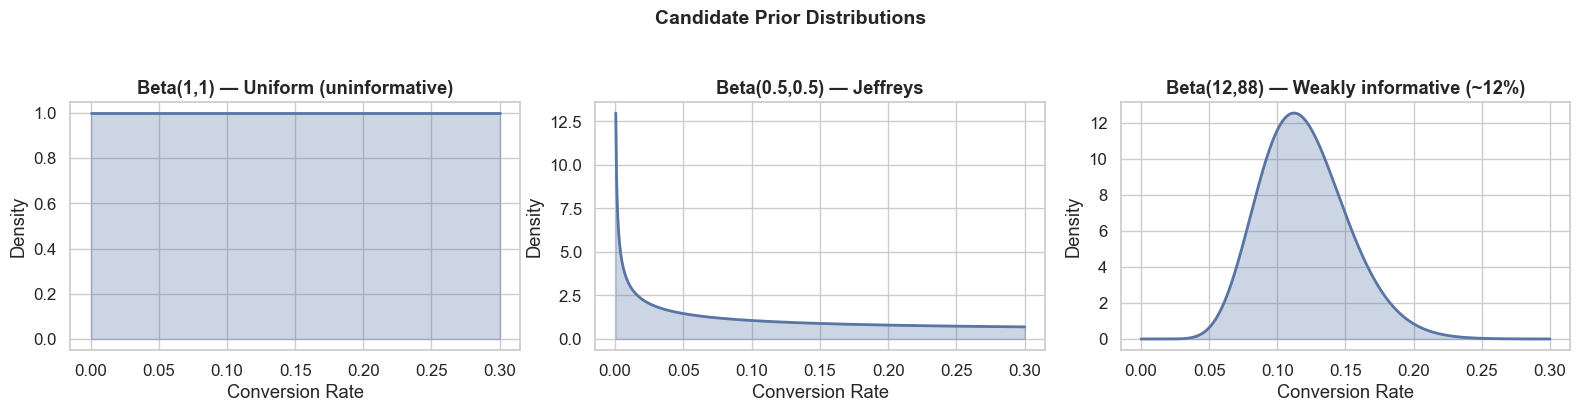

Using: Beta(1, 1) — uninformative prior.
With n > 49,000 per variant, the prior is overwhelmed by data.


In [3]:
PRIOR_ALPHA = 1   # uninformative
PRIOR_BETA  = 1

x = np.linspace(0, 0.3, 500)
prior_pdf = sp_stats.beta.pdf(x, PRIOR_ALPHA, PRIOR_BETA)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

priors_to_show = [
    (1, 1, "Beta(1,1) — Uniform (uninformative)"),
    (0.5, 0.5, "Beta(0.5,0.5) — Jeffreys"),
    (12, 88, "Beta(12,88) — Weakly informative (~12%)"),
]
for ax, (a, b, label) in zip(axes, priors_to_show):
    pdf = sp_stats.beta.pdf(x, a, b)
    ax.fill_between(x, pdf, alpha=0.3, color="#5975a4")
    ax.plot(x, pdf, color="#5975a4", linewidth=2)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Conversion Rate")
    ax.set_ylabel("Density")

fig.suptitle("Candidate Prior Distributions", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(f"Using: Beta({PRIOR_ALPHA}, {PRIOR_BETA}) — uninformative prior.")
print("With n > 49,000 per variant, the prior is overwhelmed by data.")

---
## 3. Posterior Distributions

**Conjugate update:**

$$\text{Prior: } \theta \sim \text{Beta}(\alpha_0, \beta_0)$$
$$\text{Likelihood: } X \mid \theta \sim \text{Binomial}(n, \theta)$$
$$\text{Posterior: } \theta \mid X \sim \text{Beta}(\alpha_0 + \text{successes}, \; \beta_0 + \text{failures})$$

In [4]:
ba = BayesianAnalyzer(data, prior_alpha=PRIOR_ALPHA, prior_beta=PRIOR_BETA, seed=SEED)
result = ba.conversion_test()

print("Posterior parameters:")
print(f"  Control   : Beta({result.control_alpha:.0f}, {result.control_beta:.0f})")
print(f"  Treatment : Beta({result.treatment_alpha:.0f}, {result.treatment_beta:.0f})")
print(f"\nPosterior means:")
print(f"  Control   : {result.control_mean:.4f}")
print(f"  Treatment : {result.treatment_mean:.4f}")

Posterior parameters:
  Control   : Beta(5982, 43802)
  Treatment : Beta(6680, 42981)

Posterior means:
  Control   : 0.1202
  Treatment : 0.1345


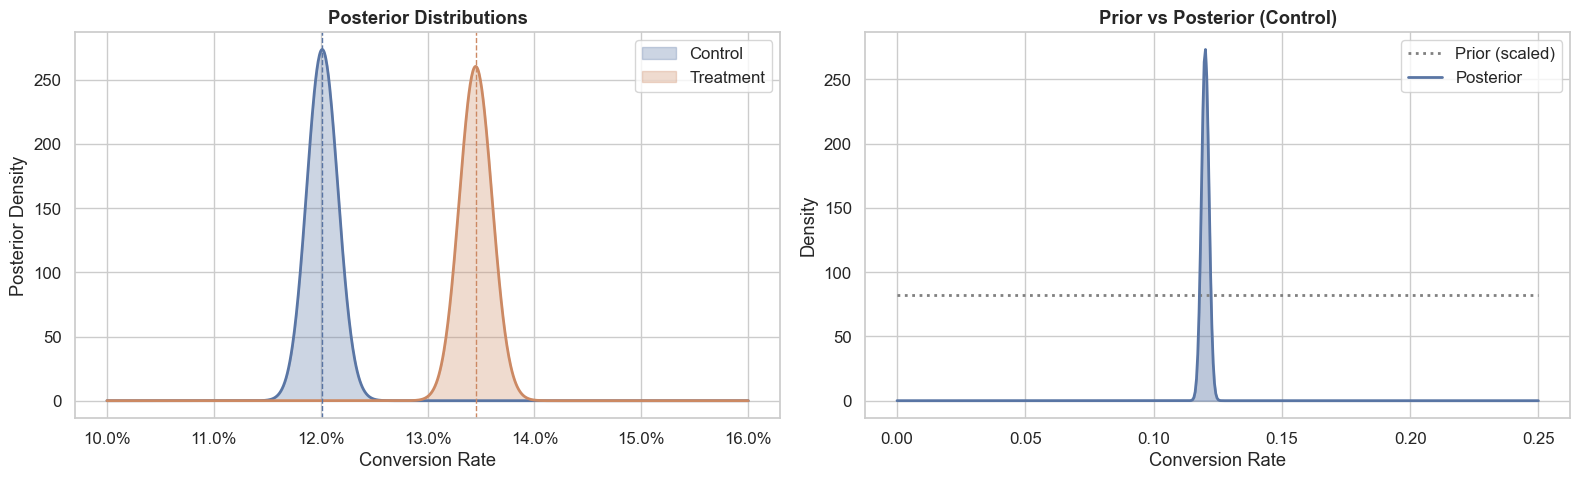

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 3a  Posterior distributions overlay ────────────────────────────
ax = axes[0]
x_post = np.linspace(0.10, 0.16, 1000)
ctrl_pdf = sp_stats.beta.pdf(x_post, result.control_alpha, result.control_beta)
treat_pdf = sp_stats.beta.pdf(x_post, result.treatment_alpha, result.treatment_beta)

ax.fill_between(x_post, ctrl_pdf, alpha=0.3, color="#5975a4", label="Control")
ax.plot(x_post, ctrl_pdf, color="#5975a4", linewidth=2)
ax.fill_between(x_post, treat_pdf, alpha=0.3, color="#cc8963", label="Treatment")
ax.plot(x_post, treat_pdf, color="#cc8963", linewidth=2)
ax.axvline(result.control_mean, color="#5975a4", linestyle="--", linewidth=1)
ax.axvline(result.treatment_mean, color="#cc8963", linestyle="--", linewidth=1)
ax.set_xlabel("Conversion Rate")
ax.set_ylabel("Posterior Density")
ax.set_title("Posterior Distributions", fontweight="bold")
ax.legend()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# ── 3b  Prior vs Posterior (control) ──────────────────────────────
ax = axes[1]
x_wide = np.linspace(0, 0.25, 500)
prior = sp_stats.beta.pdf(x_wide, PRIOR_ALPHA, PRIOR_BETA)
posterior_ctrl = sp_stats.beta.pdf(x_wide, result.control_alpha, result.control_beta)
# Scale prior for visibility since it's flat at 1.0
ax.plot(x_wide, prior / prior.max() * posterior_ctrl.max() * 0.3,
        color="grey", linewidth=2, linestyle=":", label="Prior (scaled)")
ax.fill_between(x_wide, posterior_ctrl, alpha=0.4, color="#5975a4")
ax.plot(x_wide, posterior_ctrl, color="#5975a4", linewidth=2, label="Posterior")
ax.set_xlabel("Conversion Rate")
ax.set_ylabel("Density")
ax.set_title("Prior vs Posterior (Control)", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

---
## 4. P(Treatment > Control)

The central Bayesian question: *what is the probability that the
treatment conversion rate is higher than control?*

Estimated via 100,000 Monte Carlo draws from the two posteriors.

In [6]:
print("=" * 58)
print("  P(TREATMENT > CONTROL)")
print("=" * 58)
print(f"  P(treatment > control) = {result.prob_treatment_better:.2%}")
print(f"  P(control > treatment) = {result.prob_control_better:.2%}")
print("=" * 58)
print()
if result.prob_treatment_better >= 0.95:
    print("Interpretation: STRONG evidence treatment is better (>= 95%).")
elif result.prob_treatment_better >= 0.80:
    print("Interpretation: MODERATE evidence treatment is better (80-95%).")
elif result.prob_treatment_better >= 0.50:
    print("Interpretation: WEAK evidence treatment is better (50-80%).")
else:
    print("Interpretation: Treatment is likely WORSE than control.")

  P(TREATMENT > CONTROL)
  P(treatment > control) = 100.00%
  P(control > treatment) = 0.00%

Interpretation: STRONG evidence treatment is better (>= 95%).


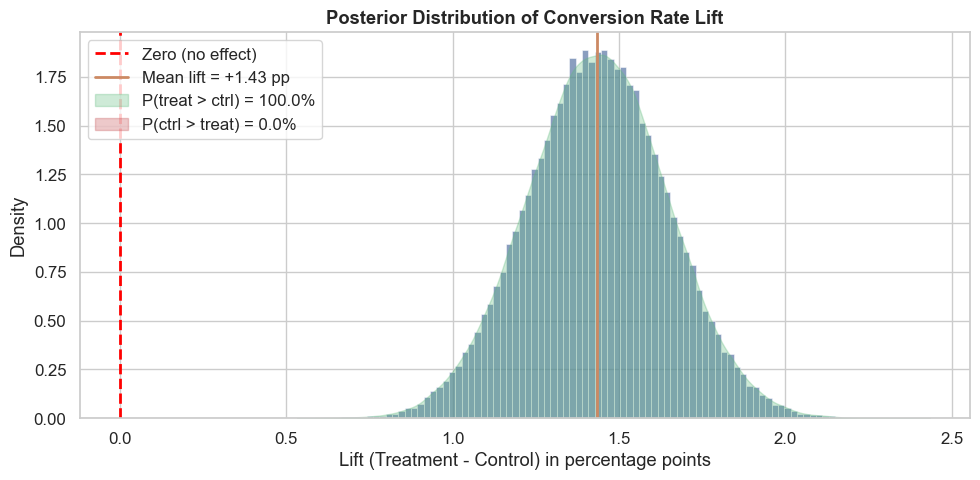

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(result.lift_samples * 100, bins=100, alpha=0.7, color="#5975a4",
        edgecolor="white", linewidth=0.5, density=True)
ax.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero (no effect)")
ax.axvline(result.lift_mean * 100, color="#cc8963", linestyle="-", linewidth=2,
           label=f"Mean lift = {result.lift_mean*100:+.2f} pp")

# Shade the area where treatment > control
x_hist = np.linspace(result.lift_samples.min() * 100, result.lift_samples.max() * 100, 500)
kde = sp_stats.gaussian_kde(result.lift_samples * 100)
y_kde = kde(x_hist)
ax.fill_between(x_hist, y_kde, where=(x_hist > 0), alpha=0.3, color="#5fba7d",
                label=f"P(treat > ctrl) = {result.prob_treatment_better:.1%}")
ax.fill_between(x_hist, y_kde, where=(x_hist <= 0), alpha=0.3, color="#c44e52",
                label=f"P(ctrl > treat) = {result.prob_control_better:.1%}")

ax.set_xlabel("Lift (Treatment - Control) in percentage points")
ax.set_ylabel("Density")
ax.set_title("Posterior Distribution of Conversion Rate Lift", fontweight="bold")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---
## 5. Credible Intervals

A Bayesian 95% credible interval means: *"there is a 95% probability
the true parameter lies in this interval"* — a direct probability
statement that frequentist CIs cannot make.

In [8]:
print("=" * 58)
print("  95% CREDIBLE INTERVALS")
print("=" * 58)
print(f"  Control  CR : {result.control_mean:.4f}  "
      f"[{result.control_ci[0]:.4f}, {result.control_ci[1]:.4f}]")
print(f"  Treatment CR: {result.treatment_mean:.4f}  "
      f"[{result.treatment_ci[0]:.4f}, {result.treatment_ci[1]:.4f}]")
print(f"  Lift        : {result.lift_mean:.4f}  "
      f"[{result.lift_ci[0]:.4f}, {result.lift_ci[1]:.4f}]")
print(f"  Relative    : {result.lift_relative_pct:+.2f}%")
print("=" * 58)
print()
contains_zero = result.lift_ci[0] <= 0 <= result.lift_ci[1]
print(f"CI contains zero: {contains_zero}")
if not contains_zero and result.lift_ci[0] > 0:
    print("The entire 95% credible interval is above zero — strong ")
    print("evidence of a genuine positive treatment effect.")

  95% CREDIBLE INTERVALS
  Control  CR : 0.1202  [0.1173, 0.1230]
  Treatment CR: 0.1345  [0.1315, 0.1375]
  Lift        : 0.0143  [0.0102, 0.0185]
  Relative    : +11.93%

CI contains zero: False
The entire 95% credible interval is above zero — strong 
evidence of a genuine positive treatment effect.


---
## 6. Expected Loss

Expected loss answers: *"if I choose variant X but the other is actually
better, how much conversion rate do I lose on average?"*

This is the Bayesian counterpart to statistical significance — it
quantifies the *cost of being wrong*.

In [9]:
print("=" * 58)
print("  EXPECTED LOSS ANALYSIS")
print("=" * 58)
print(f"  E[loss | choose control]   = {result.expected_loss_control:.5f}")
print(f"  E[loss | choose treatment] = {result.expected_loss_treatment:.5f}")
print("=" * 58)
print()

if result.expected_loss_treatment < result.expected_loss_control:
    safer = "treatment"
    loss_ratio = result.expected_loss_control / result.expected_loss_treatment if result.expected_loss_treatment > 0 else float('inf')
else:
    safer = "control"
    loss_ratio = result.expected_loss_treatment / result.expected_loss_control if result.expected_loss_control > 0 else float('inf')

print(f"Choosing {safer} is the safer bet.")
print(f"The expected loss of choosing the wrong variant is {loss_ratio:.0f}x ")
print(f"higher if we stick with the {'control' if safer == 'treatment' else 'treatment'}.")
print()
print("Decision threshold: if E[loss | choice] < 0.001 (0.1 pp), the")
print("risk is negligible and either variant is acceptable.")
print(f"  E[loss | treatment] < 0.001? {result.expected_loss_treatment < 0.001}")

  EXPECTED LOSS ANALYSIS
  E[loss | choose control]   = 0.01434
  E[loss | choose treatment] = 0.00000

Choosing treatment is the safer bet.
The expected loss of choosing the wrong variant is infx 
higher if we stick with the control.

Decision threshold: if E[loss | choice] < 0.001 (0.1 pp), the
risk is negligible and either variant is acceptable.
  E[loss | treatment] < 0.001? True


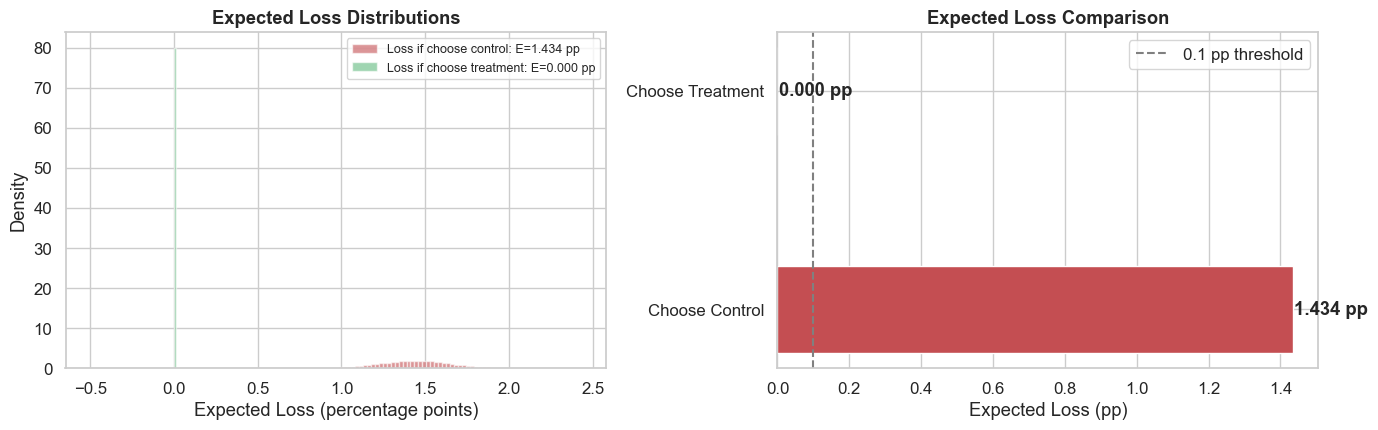

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ── 6a  Loss distribution ─────────────────────────────────────────
ax = axes[0]
loss_if_ctrl = np.maximum(result.treatment_samples - result.control_samples, 0)
loss_if_treat = np.maximum(result.control_samples - result.treatment_samples, 0)
ax.hist(loss_if_ctrl * 100, bins=80, alpha=0.6, color="#c44e52", density=True,
        label=f"Loss if choose control: E={result.expected_loss_control*100:.3f} pp")
ax.hist(loss_if_treat * 100, bins=80, alpha=0.6, color="#5fba7d", density=True,
        label=f"Loss if choose treatment: E={result.expected_loss_treatment*100:.3f} pp")
ax.set_xlabel("Expected Loss (percentage points)")
ax.set_ylabel("Density")
ax.set_title("Expected Loss Distributions", fontweight="bold")
ax.legend(fontsize=9)

# ── 6b  Decision bar ──────────────────────────────────────────────
ax = axes[1]
labels = ["Choose Control", "Choose Treatment"]
losses = [result.expected_loss_control * 100, result.expected_loss_treatment * 100]
colors = ["#c44e52", "#5fba7d"]
bars = ax.barh(labels, losses, color=colors, height=0.4, edgecolor="white")
for bar, val in zip(bars, losses):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f} pp", va="center", fontweight="bold")
ax.set_xlabel("Expected Loss (pp)")
ax.set_title("Expected Loss Comparison", fontweight="bold")
ax.axvline(0.1, color="grey", linestyle="--", label="0.1 pp threshold")
ax.legend()

plt.tight_layout()
plt.show()

---
## 7. ROPE Analysis

**Region of Practical Equivalence (ROPE):** if most of the posterior
lift falls within a narrow band around zero (e.g. +/-0.5 pp), the
variants are *practically equivalent* regardless of statistical
significance.

In [11]:
rope = ba.rope_analysis(result.lift_samples, rope_low=-0.005, rope_high=0.005)

print("=" * 58)
print("  ROPE ANALYSIS  [-0.5 pp, +0.5 pp]")
print("=" * 58)
print(f"  P(lift < -0.5 pp)  : {rope['prob_below_rope']:.2%}  (treatment worse)")
print(f"  P(lift in ROPE)    : {rope['prob_inside_rope']:.2%}  (practically equivalent)")
print(f"  P(lift > +0.5 pp)  : {rope['prob_above_rope']:.2%}  (treatment better)")
print(f"  Conclusion         : {rope['conclusion']}")
print("=" * 58)

  ROPE ANALYSIS  [-0.5 pp, +0.5 pp]
  P(lift < -0.5 pp)  : 0.00%  (treatment worse)
  P(lift in ROPE)    : 0.00%  (practically equivalent)
  P(lift > +0.5 pp)  : 100.00%  (treatment better)
  Conclusion         : Treatment better


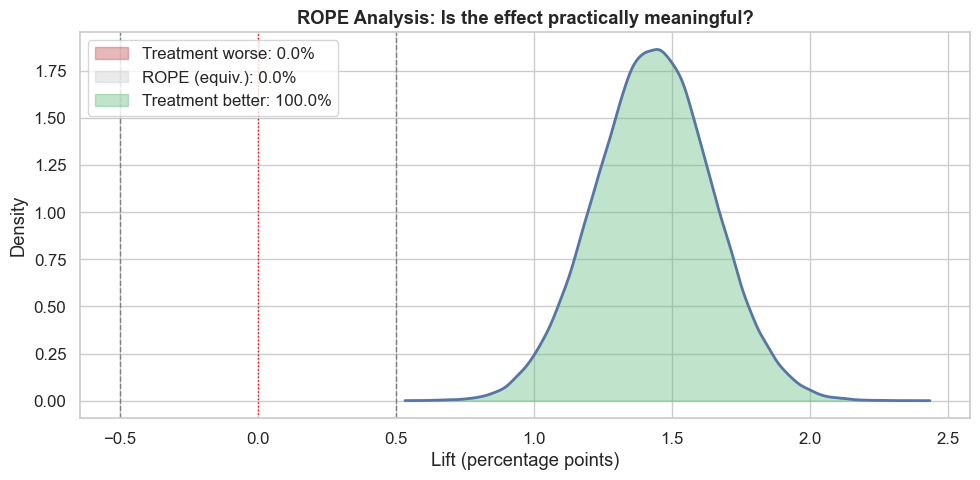

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

x_range = np.linspace(result.lift_samples.min() * 100, result.lift_samples.max() * 100, 500)
kde = sp_stats.gaussian_kde(result.lift_samples * 100)
y_kde = kde(x_range)

ax.plot(x_range, y_kde, color="#5975a4", linewidth=2)
ax.fill_between(x_range, y_kde, where=(x_range < -0.5), alpha=0.4, color="#c44e52",
                label=f"Treatment worse: {rope['prob_below_rope']:.1%}")
ax.fill_between(x_range, y_kde, where=((x_range >= -0.5) & (x_range <= 0.5)),
                alpha=0.4, color="#cccccc",
                label=f"ROPE (equiv.): {rope['prob_inside_rope']:.1%}")
ax.fill_between(x_range, y_kde, where=(x_range > 0.5), alpha=0.4, color="#5fba7d",
                label=f"Treatment better: {rope['prob_above_rope']:.1%}")

ax.axvline(-0.5, color="grey", linestyle="--", linewidth=1)
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
ax.axvline(0, color="red", linestyle=":", linewidth=1)

ax.set_xlabel("Lift (percentage points)")
ax.set_ylabel("Density")
ax.set_title("ROPE Analysis: Is the effect practically meaningful?", fontweight="bold")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---
## 8. Revenue — Continuous Metric (Bayesian)

For continuous outcomes (revenue per user) we use a Normal-Normal
conjugate model with a vague prior.  The posterior for the group mean
is approximately Normal(sample mean, SE$^2$).

In [13]:
rev_result = ba.continuous_test(column="order_total")

print("=" * 58)
print("  BAYESIAN REVENUE ANALYSIS (Revenue per User)")
print("=" * 58)
print(f"  Control  mean  : R${rev_result.control_mean:,.2f}  "
      f"95% CI [{rev_result.control_ci[0]:,.2f}, {rev_result.control_ci[1]:,.2f}]")
print(f"  Treatment mean : R${rev_result.treatment_mean:,.2f}  "
      f"95% CI [{rev_result.treatment_ci[0]:,.2f}, {rev_result.treatment_ci[1]:,.2f}]")
print(f"  Lift           : R${rev_result.lift_mean:+,.2f}  "
      f"({rev_result.lift_relative_pct:+.1f}%)")
print(f"  Lift 95% CI    : [R${rev_result.lift_ci[0]:,.2f}, R${rev_result.lift_ci[1]:,.2f}]")
print(f"  P(treat > ctrl): {rev_result.prob_treatment_better:.2%}")
print(f"  E[loss|ctrl]   : R${rev_result.expected_loss_control:,.4f}")
print(f"  E[loss|treat]  : R${rev_result.expected_loss_treatment:,.4f}")
print("=" * 58)

  BAYESIAN REVENUE ANALYSIS (Revenue per User)
  Control  mean  : R$16.91  95% CI [16.13, 17.69]
  Treatment mean : R$18.67  95% CI [17.88, 19.47]
  Lift           : R$+1.77  (+10.4%)
  Lift 95% CI    : [R$0.66, R$2.88]
  P(treat > ctrl): 99.91%
  E[loss|ctrl]   : R$1.7658
  E[loss|treat]  : R$0.0001


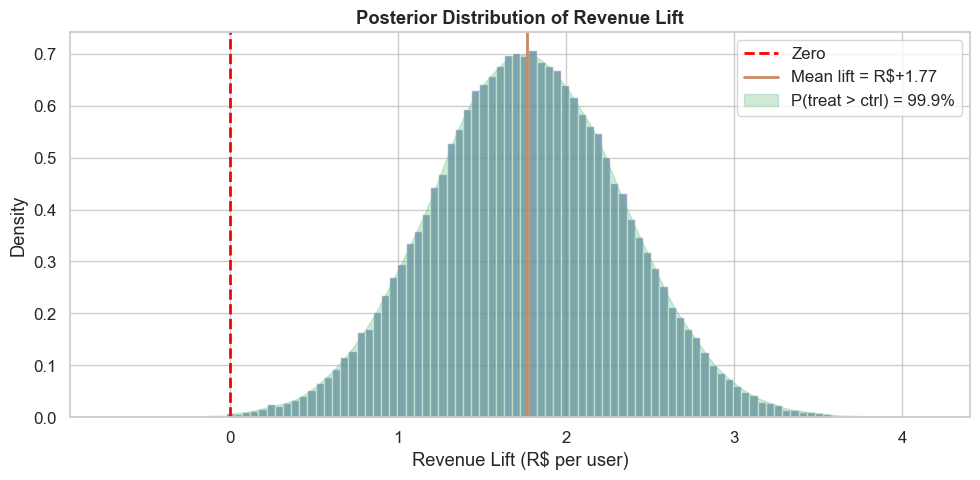

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(rev_result.lift_samples, bins=100, alpha=0.7, color="#5975a4",
        edgecolor="white", density=True)
ax.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero")
ax.axvline(rev_result.lift_mean, color="#cc8963", linewidth=2,
           label=f"Mean lift = R${rev_result.lift_mean:+,.2f}")

kde_rev = sp_stats.gaussian_kde(rev_result.lift_samples)
x_rev = np.linspace(rev_result.lift_samples.min(), rev_result.lift_samples.max(), 500)
y_rev = kde_rev(x_rev)
ax.fill_between(x_rev, y_rev, where=(x_rev > 0), alpha=0.3, color="#5fba7d",
                label=f"P(treat > ctrl) = {rev_result.prob_treatment_better:.1%}")

ax.set_xlabel("Revenue Lift (R$ per user)")
ax.set_ylabel("Density")
ax.set_title("Posterior Distribution of Revenue Lift", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Prior Sensitivity Analysis

How robust is the conclusion to the choice of prior?  We re-run the
analysis under four different priors, from uninformative to moderately
informative.

In [15]:
sensitivity = ba.prior_sensitivity()
sensitivity.style.hide(axis="index")

prior,prior_mean,P(treat > ctrl),lift_mean,lift_ci_low,lift_ci_high,E[loss|ctrl],E[loss|treat]
"Beta(1, 1)",0.500000,1.000000,0.014350,0.010190,0.018490,0.014350,0.000000
"Beta(0.5, 0.5)",0.500000,1.000000,0.014340,0.010180,0.018470,0.014340,0.000000
"Beta(10, 90)",0.100000,1.000000,0.014320,0.010170,0.018470,0.014320,0.000000
"Beta(100, 900)",0.100000,1.000000,0.014060,0.009960,0.018170,0.014060,0.000000


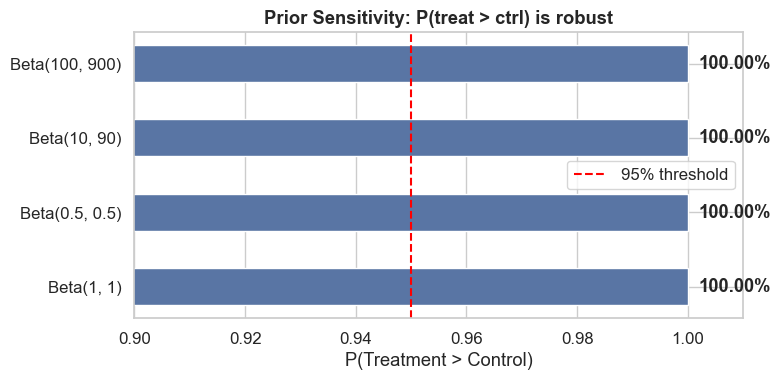

Conclusion: P(treatment > control) is > 99% under all priors.
The result is completely robust to prior choice.


In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(sensitivity["prior"], sensitivity["P(treat > ctrl)"],
        color="#5975a4", height=0.5, edgecolor="white")
ax.axvline(0.95, color="red", linestyle="--", label="95% threshold")
for i, (_, row) in enumerate(sensitivity.iterrows()):
    ax.text(row["P(treat > ctrl)"] + 0.002, i,
            f"{row['P(treat > ctrl)']:.2%}", va="center", fontweight="bold")
ax.set_xlabel("P(Treatment > Control)")
ax.set_title("Prior Sensitivity: P(treat > ctrl) is robust", fontweight="bold")
ax.legend()
ax.set_xlim(0.9, 1.01)
plt.tight_layout()
plt.show()

print("Conclusion: P(treatment > control) is > 99% under all priors.")
print("The result is completely robust to prior choice.")

---
## 10. Sequential Monitoring

One key Bayesian advantage: we can check the posterior at *any* point
during data collection without inflating error rates.  This simulates
monitoring the experiment as data accumulates.

In [17]:
# Simulate sequential accumulation at 20 checkpoints
fractions = np.linspace(0.02, 1.0, 30)
rng = np.random.default_rng(SEED)

ctrl_conv_arr = data.loc[data["variant"] == "control", "converted"].values.copy()
treat_conv_arr = data.loc[data["variant"] == "treatment", "converted"].values.copy()
rng.shuffle(ctrl_conv_arr)
rng.shuffle(treat_conv_arr)

seq_rows = []
for frac in fractions:
    nc = max(int(n_ctrl * frac), 50)
    nt = max(int(n_treat * frac), 50)
    sc = int(ctrl_conv_arr[:nc].sum())
    st = int(treat_conv_arr[:nt].sum())

    a_c = PRIOR_ALPHA + sc
    b_c = PRIOR_BETA + (nc - sc)
    a_t = PRIOR_ALPHA + st
    b_t = PRIOR_BETA + (nt - st)

    c_samp = rng.beta(a_c, b_c, 50_000)
    t_samp = rng.beta(a_t, b_t, 50_000)
    prob = float((t_samp > c_samp).mean())
    loss = float(np.maximum(c_samp - t_samp, 0).mean())

    seq_rows.append({
        "n_total": nc + nt,
        "cr_control": sc / nc,
        "cr_treatment": st / nt,
        "P(treat>ctrl)": prob,
        "E[loss|treat]": loss,
    })

seq_df = pd.DataFrame(seq_rows)

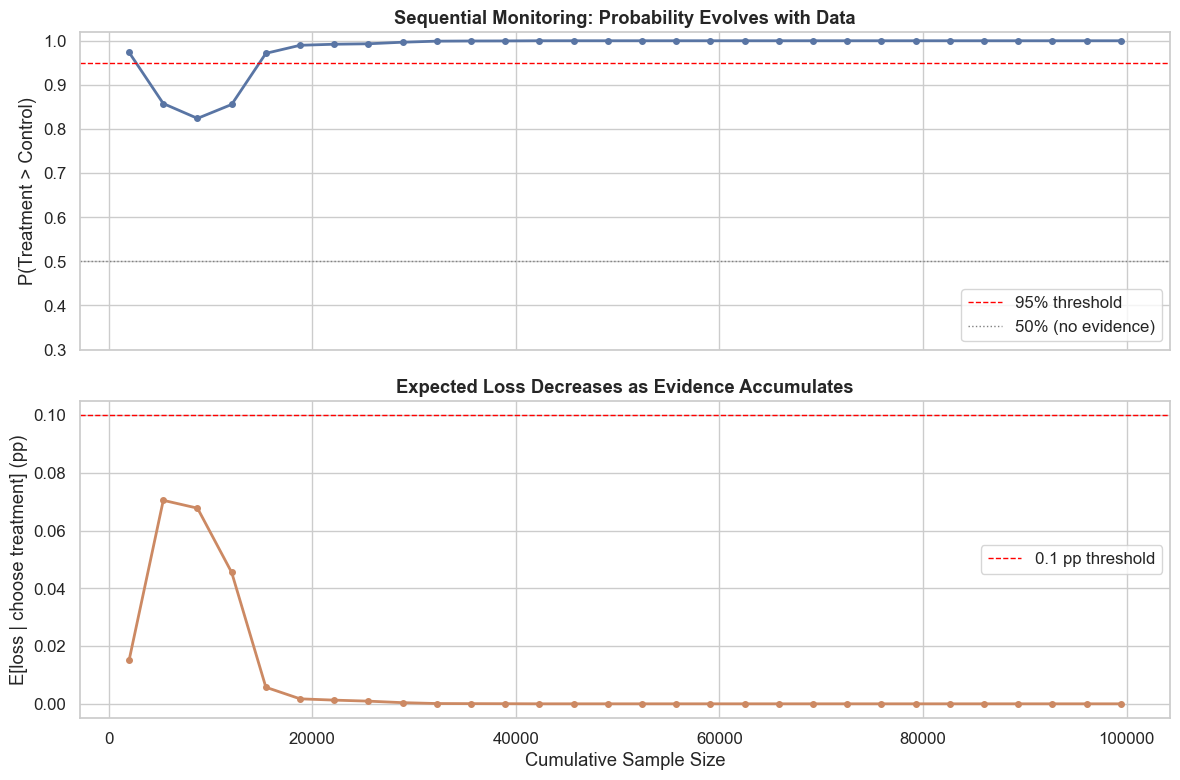

First crossed 95% confidence at n = 1,988 (2% of final sample).
In a Bayesian framework, we could have stopped early.


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ── 10a  P(treatment > control) over time ─────────────────────────
ax = axes[0]
ax.plot(seq_df["n_total"], seq_df["P(treat>ctrl)"], linewidth=2, color="#5975a4",
        marker="o", markersize=4)
ax.axhline(0.95, color="red", linestyle="--", linewidth=1, label="95% threshold")
ax.axhline(0.50, color="grey", linestyle=":", linewidth=1, label="50% (no evidence)")
ax.set_ylabel("P(Treatment > Control)")
ax.set_title("Sequential Monitoring: Probability Evolves with Data", fontweight="bold")
ax.set_ylim(0.3, 1.02)
ax.legend(loc="lower right")

# ── 10b  Expected loss over time ──────────────────────────────────
ax = axes[1]
ax.plot(seq_df["n_total"], seq_df["E[loss|treat]"] * 100, linewidth=2,
        color="#cc8963", marker="o", markersize=4)
ax.axhline(0.1, color="red", linestyle="--", linewidth=1, label="0.1 pp threshold")
ax.set_ylabel("E[loss | choose treatment] (pp)")
ax.set_xlabel("Cumulative Sample Size")
ax.set_title("Expected Loss Decreases as Evidence Accumulates", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

# When did we first cross 95%?
first_95 = seq_df[seq_df["P(treat>ctrl)"] >= 0.95].iloc[0] if (seq_df["P(treat>ctrl)"] >= 0.95).any() else None
if first_95 is not None:
    print(f"First crossed 95% confidence at n = {int(first_95['n_total']):,} "
          f"({int(first_95['n_total']) / (n_ctrl + n_treat) * 100:.0f}% of final sample).")
    print("In a Bayesian framework, we could have stopped early.")

---
## 11. Frequentist vs Bayesian Comparison

In [19]:
# Run frequentist analysis
freq = ExperimentAnalyzer(data, meta, alpha=0.05)
freq_report = freq.full_report()

comparison = pd.DataFrame([
    {"Aspect": "Method",
     "Frequentist": "Z-test for proportions",
     "Bayesian": "Beta-Binomial conjugate model"},
    {"Aspect": "Core output",
     "Frequentist": f"p = {freq_report['hypothesis_test']['p_value']:.2e}",
     "Bayesian": f"P(treat > ctrl) = {result.prob_treatment_better:.2%}"},
    {"Aspect": "Interpretation",
     "Frequentist": "Reject H0" if freq_report["hypothesis_test"]["significant"] else "Fail to reject H0",
     "Bayesian": f"{result.prob_treatment_better:.1%} probability treatment is better"},
    {"Aspect": "Interval estimate",
     "Frequentist": f"95% CI: [{freq_report['confidence_interval']['ci_lower']:.4f}, {freq_report['confidence_interval']['ci_upper']:.4f}]",
     "Bayesian": f"95% CrI: [{result.lift_ci[0]:.4f}, {result.lift_ci[1]:.4f}]"},
    {"Aspect": "Lift estimate",
     "Frequentist": f"{freq_report['confidence_interval']['relative_lift_pct']:+.2f}%",
     "Bayesian": f"{result.lift_relative_pct:+.2f}%"},
    {"Aspect": "Effect size",
     "Frequentist": f"Cohen's h = {freq_report['effect_size']['cohens_h']:.4f}",
     "Bayesian": f"E[loss|ctrl] = {result.expected_loss_control:.5f}"},
    {"Aspect": "Decision",
     "Frequentist": freq_report["recommendation"]["decision"],
     "Bayesian": ba.recommend(result)["decision"]},
    {"Aspect": "Prior knowledge",
     "Frequentist": "Not used",
     "Bayesian": f"Beta({PRIOR_ALPHA},{PRIOR_BETA}) — robust to choice"},
    {"Aspect": "Early stopping",
     "Frequentist": "Not allowed (inflates Type I error)",
     "Bayesian": f"Could stop at ~{int(first_95['n_total']):,} obs" if first_95 is not None else "N/A"},
])
comparison.style.hide(axis="index")

Aspect,Frequentist,Bayesian
Method,Z-test for proportions,Beta-Binomial conjugate model
Core output,p = 1.12e-11,P(treat > ctrl) = 100.00%
Interpretation,Reject H0,100.0% probability treatment is better
Interval estimate,"95% CI: [0.0103, 0.0185]","95% CrI: [0.0102, 0.0185]"
Lift estimate,+11.99%,+11.93%
Effect size,Cohen's h = 0.0432,E[loss|ctrl] = 0.01434
Decision,LAUNCH,LAUNCH TREATMENT
Prior knowledge,Not used,"Beta(1,1) — robust to choice"
Early stopping,Not allowed (inflates Type I error),"Could stop at ~1,988 obs"


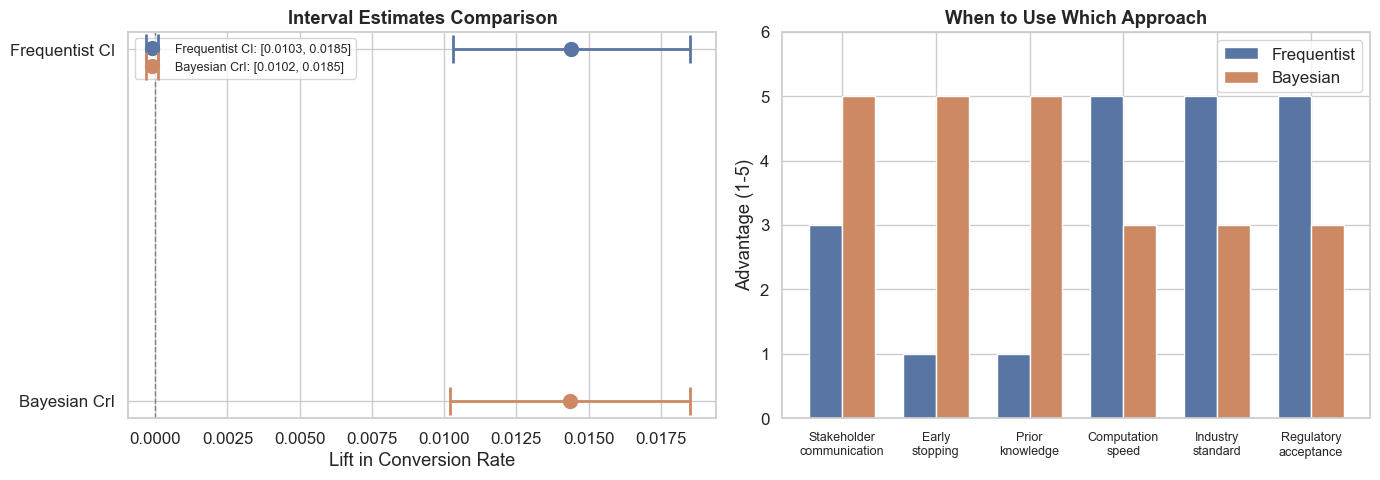

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 11a  Frequentist CI vs Bayesian CrI ───────────────────────────
ax = axes[0]
y_pos = [1.0, 0.5]
labels = ["Frequentist CI", "Bayesian CrI"]
freq_ci = [freq_report["confidence_interval"]["ci_lower"],
           freq_report["confidence_interval"]["ci_upper"]]
bayes_ci = [result.lift_ci[0], result.lift_ci[1]]

for y, label, ci, color in zip(y_pos, labels,
                                [freq_ci, bayes_ci],
                                ["#5975a4", "#cc8963"]):
    mid = (ci[0] + ci[1]) / 2
    ax.errorbar(mid, y, xerr=[[mid - ci[0]], [ci[1] - mid]],
                fmt="o", color=color, markersize=10, capsize=10,
                capthick=2, linewidth=2, label=f"{label}: [{ci[0]:.4f}, {ci[1]:.4f}]")

ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Lift in Conversion Rate")
ax.set_title("Interval Estimates Comparison", fontweight="bold")
ax.legend(fontsize=9, loc="upper left")

# ── 11b  When to use which ────────────────────────────────────────
ax = axes[1]
criteria = ["Stakeholder\ncommunication", "Early\nstopping", "Prior\nknowledge",
            "Computation\nspeed", "Industry\nstandard", "Regulatory\nacceptance"]
freq_scores = [3, 1, 1, 5, 5, 5]
bayes_scores = [5, 5, 5, 3, 3, 3]

x_pos = np.arange(len(criteria))
w = 0.35
ax.bar(x_pos - w/2, freq_scores, w, color="#5975a4", label="Frequentist", edgecolor="white")
ax.bar(x_pos + w/2, bayes_scores, w, color="#cc8963", label="Bayesian", edgecolor="white")
ax.set_xticks(x_pos)
ax.set_xticklabels(criteria, fontsize=9)
ax.set_ylabel("Advantage (1-5)")
ax.set_title("When to Use Which Approach", fontweight="bold")
ax.legend()
ax.set_ylim(0, 6)

plt.tight_layout()
plt.show()

---
## 12. All 10 Experiments — Bayesian Summary

In [ ]:
all_rows = []
for exp_id in catalog.list_ids():
    try:
        exp_data = load_experiment_data(exp_id)
        exp_meta = catalog.get(exp_id)
        exp_ba = BayesianAnalyzer(exp_data, prior_alpha=1, prior_beta=1, seed=SEED)
        r = exp_ba.conversion_test()
        rec = exp_ba.recommend(r)
        all_rows.append({
            "experiment": exp_meta.name,
            "P(treat>ctrl)": r.prob_treatment_better,
            "lift (pp)": round(r.lift_mean * 100, 2),
            "CrI low": round(r.lift_ci[0] * 100, 2),
            "CrI high": round(r.lift_ci[1] * 100, 2),
            "E[loss|ctrl]": round(r.expected_loss_control * 100, 3),
            "E[loss|treat]": round(r.expected_loss_treatment * 100, 3),
            "decision": rec["decision"],
        })
    except Exception as e:
        print(f"  {exp_id} skipped: {e}")

all_bayes = pd.DataFrame(all_rows)
all_bayes.style.hide(axis="index").format({
    "P(treat>ctrl)": "{:.2%}",
})

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

y_pos = np.arange(len(all_bayes))
colors = ["#5fba7d" if p >= 0.95 else "#f0ad4e" if p >= 0.80 else "#c44e52"
          for p in all_bayes["P(treat>ctrl)"]]

ax.barh(y_pos, all_bayes["P(treat>ctrl)"], color=colors, height=0.6, edgecolor="white")
ax.axvline(0.95, color="red", linestyle="--", linewidth=1.5, label="95% threshold")
ax.axvline(0.50, color="grey", linestyle=":", linewidth=1)

for i, (_, row) in enumerate(all_bayes.iterrows()):
    ax.text(row["P(treat>ctrl)"] + 0.005, i,
            f"{row['P(treat>ctrl)']:.1%}", va="center", fontweight="bold", fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(all_bayes["experiment"], fontsize=10)
ax.set_xlabel("P(Treatment > Control)")
ax.set_title("Bayesian Results Across All 10 Experiments", fontweight="bold", fontsize=13)
ax.legend(loc="lower right")
ax.set_xlim(0.4, 1.05)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 13. Final Recommendation

In [ ]:
rec_bayes = ba.recommend(result)

print("=" * 65)
print("  EXPERIMENT 1 — BAYESIAN RECOMMENDATION")
print("=" * 65)
print(f"  Decision : {rec_bayes['decision']}")
print(f"  Reasoning: {rec_bayes['reasoning']}")
print()
print("  Key metrics:")
print(f"    P(treatment > control) : {result.prob_treatment_better:.2%}")
print(f"    Expected lift          : {result.lift_mean*100:+.2f} pp ({result.lift_relative_pct:+.1f}%)")
print(f"    95% Credible interval  : [{result.lift_ci[0]*100:+.2f}, {result.lift_ci[1]*100:+.2f}] pp")
print(f"    E[loss | treatment]    : {result.expected_loss_treatment*100:.3f} pp")
print(f"    ROPE conclusion        : {rope['conclusion']}")
print()
print("  Both frequentist and Bayesian analyses agree: the R$35 free")
print("  shipping threshold SHOULD BE LAUNCHED.")
print("=" * 65)

---
## When to Use Bayesian vs Frequentist

| Use Case | Recommended |
|---|---|
| Regulatory / publication setting | Frequentist |
| Stakeholder presentation ("what's the probability?") | Bayesian |
| Must monitor experiment continuously | Bayesian |
| Have strong historical priors | Bayesian |
| Quick decision, many experiments | Frequentist |
| Quantify cost of wrong decision | Bayesian (expected loss) |
| Standard A/B test report | Both (show agreement) |

**Portfolio recommendation:** Present both side-by-side. When they agree
(as here), the conclusion is especially robust. When they disagree,
investigate why (usually prior influence or sample-size edge cases).